# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *08*  
**Kaggle challenge:** *Classic* (either `Classic` or `Deep learning`)  
**Kaggle team name (exact):** "*ChocolateEaters8000*"  

**Author 1 (SCIPER):** *Gamper Mathys (327840)*  
**Author 2 (SCIPER):** *Schaer Mikaël (325388)*  
**Author 3 (SCIPER):** *Bastien Chesaux Dapia (325678)*  

**Due date:** 21.05.2025 (23:59 pm)




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import skimage as skim
import scipy

from scipy.ndimage import labeled_comprehension, binary_dilation
from skimage.measure import block_reduce
from skimage.segmentation import slic

from sklearn.mixture import GaussianMixture
from PIL import Image

import os

import src._utils as _utils
import src.config as config

# Chocolate Segmentation
The purpose of this section is to extract a binary mask that separates all chocolates from the background to then be postprocessed and fed to a the feature extraction methods and finally the classifier. 

Our intent was to continue to explore the concepts presented in the lectures, and test our ability to produce a pipeline that could extend to more backgrounds and chocolates. We therefore went for a selection of clustering techniques instead of manually tuned thresholds, which has proven to be more challenging than expected.

 Although it allowed us to experiment with more methods and face some new problematics, it didn't provide robust results for the rest of the pipeline and probably had a negative impact of the final score.

 In this section of the report we describe the different steps of the segmentation with an example image that gives good results. We then analyse why this part of the pipeline is fragile, what solutions we added to our implementation to reduce those weaknesses, and other potential solutions that we did not implement.

 **Important note:** Some of the elements of the pipeline being undeterministic, re-running the cells of this notebook might result in a different outcome of the one we used to illustrate our work

## Method
### Reduction of data

The 24MPX resolution of the provided images is overkill compared to the amount of information we want to extract out of them. We therefore decided to reduce their size to lighten the rest of the pipeline. This is done by binning the images with a square (10,10) median kernel, dividing by 100 the amount of data. Median is preferred to mean filtering as it preserves edges better.

In [131]:
def median_bin_rgb(image, block_size=(2, 2)):
    channels = []
    for i in range(3):
        channel = block_reduce(image[:, :, i], block_size=block_size, func=np.median)
        channels.append(channel)
    return np.stack(channels, axis=-1).astype(np.uint8)

In [ ]:

full_path = 'examples/L1000939.JPG'

img = np.array(Image.open(full_path))
binned = median_bin_rgb(img, block_size=(10, 10))

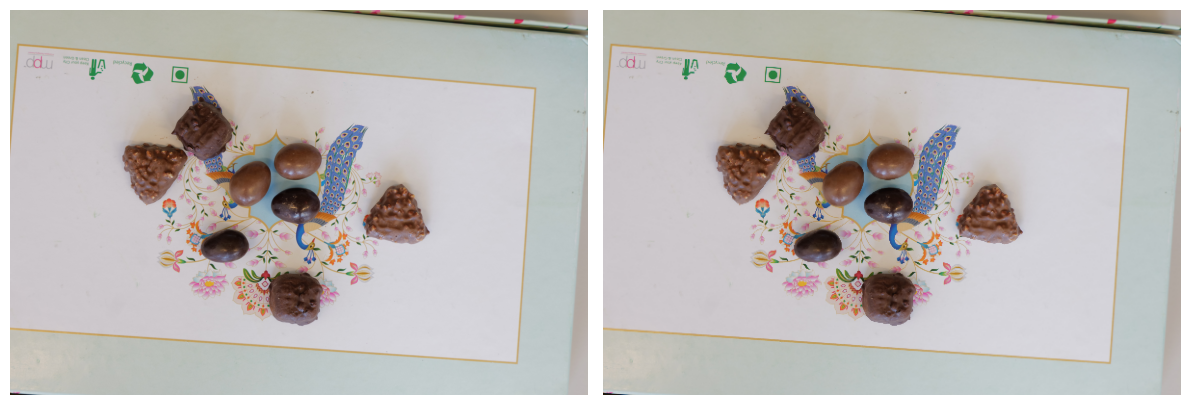

original shape: (4000, 6000, 3)
reduced shape: (400, 600, 3)


In [164]:
plt.figure(figsize=(12, 7))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(binned)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'original shape: {img.shape}\nreduced shape: {binned.shape}')

### Super pixels
SLIC (Simple Linear Iterative Clustering) is a method cluster the pixels in the image into numerous superpixels, based on their color and location. Since the higher level clustering techniques we employ to separate chocolate from background only depend on the color information of the pixels, dividing the image in superpixels allows us to extract some of the spatial information in the image. This helps avoid high frequency noise in the binary mask after clustering, and align the segmentation with the edges of the chocolate in the spatial domain. 

We can roughly control the amount of superpixels, as well as the ratio of importance between color and spatial information for clustering (compactness)

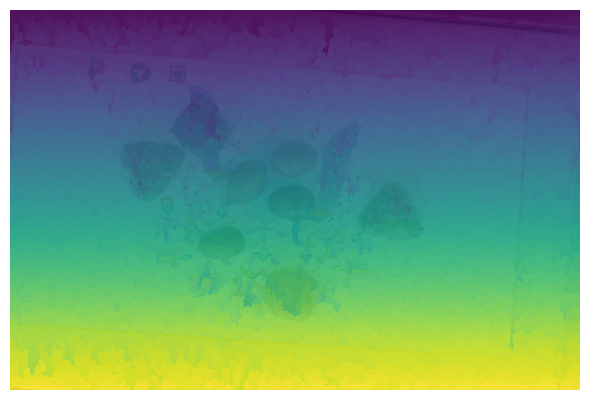

In [223]:
spx = slic(binned, n_segments=10000, compactness=.05, sigma=0.1, start_label=0)

plt.figure(figsize=(6, 8))

plt.imshow(binned)
plt.imshow(spx, alpha=0.9)
plt.axis('off')

plt.tight_layout()
plt.show()

### Low level extraction
We convert remap the image from rgb to hsv because the different kind of milk and dark chocolates lie in a small range of hue values, and this space is slightly less sensitive to lighting conditions (reflects from sideways light were a big problem in rgb). 

Because hue is an angle, some colors near the minimum value are actually close to colors near the maximum value ([0, 180] for the cv2 implementation). Since the hue of the chocolates lies near those extremas we need a way to wrap the hue values to be able to cluster chocolates together. We therefore split the hue into two components $h_x$ and $h_y$, respectively cosine and sine of $h$. We normalize h, s and v values so that they are in the range [0,1]. 

Each superpixel takes the median of those features over the pixels it contains.

In [224]:
binned_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)

In [225]:
def hsv_spx_feat(hsv_img, spx, agg_func=np.median):    
    label_ids = np.arange(spx.max() + 1)        
    h = labeled_comprehension(hsv_img[..., 0],labels=spx,index=label_ids,func=agg_func,out_dtype=float,default=np.nan)/180 #cv2 convention
    s = labeled_comprehension(hsv_img[..., 1],spx,label_ids,func=agg_func,out_dtype=float,default=np.nan)/255
    v = labeled_comprehension(hsv_img[..., 2],spx,label_ids,func=agg_func, out_dtype=float,default=np.nan)/255

    hx = np.cos(h*2*np.pi)
    hy = np.sin(h*2*np.pi)

    feat = np.array([hx, hy, s, v])
    return feat.T

In [226]:
hsv_feat = hsv_spx_feat(binned_hsv, spx, np.median)

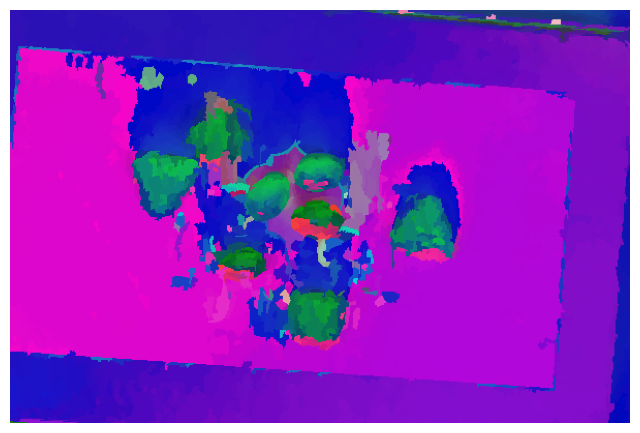

In [227]:
h = (np.atan2(hsv_feat[:,1], hsv_feat[:,0])/(2*np.pi))%1 #unwrap h
unwrapped_feat = np.vstack((h, hsv_feat[:,2], hsv_feat[:,3])).T

plt.figure(figsize=(8,6))
plt.imshow(unwrapped_feat[spx])
plt.axis('off')
plt.show()

### Custer the superpixels

We now want to use unsupervised learning techniques to cluster the supexpixels. The feature distribution of the superpixels is sparse and unbalanced. The Gaussian mixture model was chosen because it tends to perform better than K-means with unbalanced datasets. DBSCAN was also explored because it allowed to include spatial information in the clustering but we didn't manage to find a setting where it converges. 

The purpose of this step is not yet to provide a binary label that separates chocolate from background, but rather to adapt the number of clusters to the color distribution of the backgrounds and later select which cluster corresponds to chocolates.

We initially wanted to fit a GMM on the whole training set to have a representation of all the different backgrounds in one model. We could have then use this mdoel to predict labels on new images for inference. We however quickly realise that encapsulating coherent informations for all background, chocolates and objects in one model is to complex

Instead, we now fit a GMM for each image we want to analyse which results in less stable results across the dataset and is not reproducible (random initialisation of gaussian parameters), but adapts much better to the image at hand.

The number of components of the GMM is chosen based on the BIC (Bayesian information criterion) that represents a trade-off between the quality of the fit and the number of parameters of the model. We allow full covariance matrices for the gaussian components. This means that the axis of elongation of the clusters do not have to be parallel to the h, s and v axis, which is a great asset compared to distinct hand-picked thresholds for the three channels.

In [228]:
def gmm_on_spx_fit(c_range, X, plot=False):
    best_bic = np.inf
    best_gmm = None
    best_n_components = 0
    bics = []

    for c in c_range:
        gmm = GaussianMixture(n_components=c, covariance_type='full', reg_covar=1e-3)
        gmm.fit(X)
        bic = gmm.bic(X)
        bics.append(bic)
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_n_components = c
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(c_range, bics, marker='o')
        plt.title('BIC vs Number of Components')
        plt.tight_layout()
        plt.show()  

    return best_gmm

def gmm_on_spx_predict(gmm, X, spx):
    labels = gmm.predict(X.reshape((-1, X.shape[2])))
    labels = labels.reshape((spx.shape[0], spx.shape[1]))
    return labels

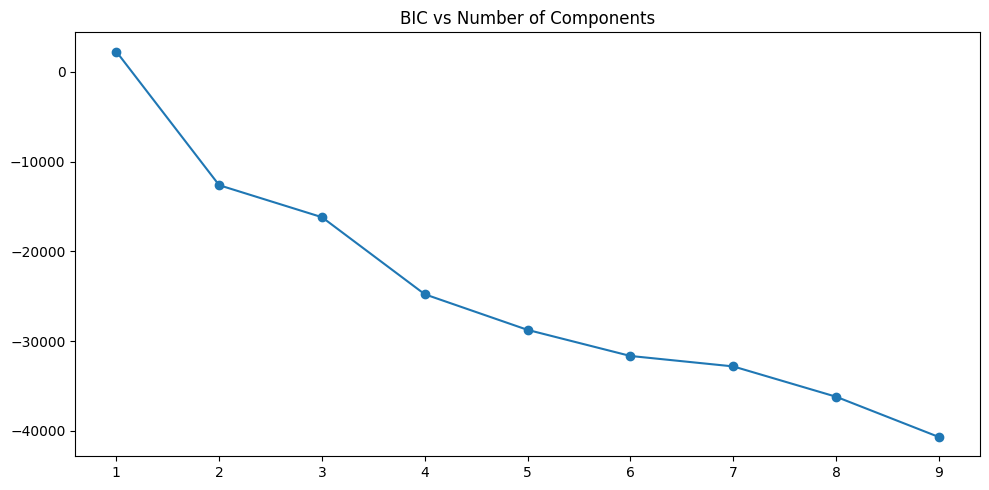

In [229]:
gmm = gmm_on_spx_fit(range(1,10), hsv_feat, True)
labels = gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

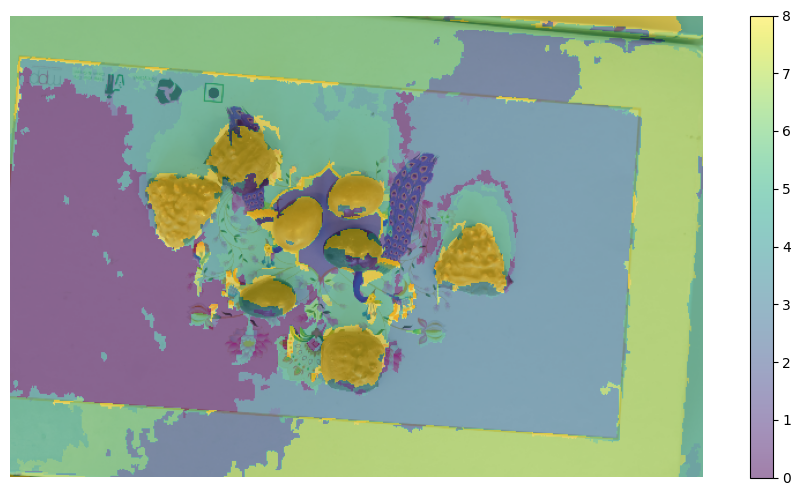

In [230]:
plt.figure(figsize=(12,6))
plt.imshow(binned)
plt.imshow(labels, alpha=0.5)
plt.colorbar()
plt.axis('off')
plt.show()

### Selection of the chocolate cluster

In order to select the cluster that contains the most chocolate, we need a reference for comparison. For this purpose, we annotated the reference picture for each chocolate. We fit a single Gaussian to get an accurate representation of the chocolate color distribution. 



In [ ]:
reference_path = 'references'
annotation_path = 'references_annotated'

feat_ref = []

names = ['Arabia', 'Jelly_Black', 'Jelly_Milk', 'Noblesse', 'Noir_authentique', 'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']


for filename in names:
    full_path = reference_path + '/' + filename + '.JPG'
    ref = np.array(Image.open(full_path))

    annot = np.array(Image.open(annotation_path+'/'+filename+'_annotated.jpg'), dtype=bool)

    binned_ref = median_bin_rgb(ref, block_size=(10, 10))
    annot = block_reduce(annot, block_size=(10,10), func=np.median)

    binned_bgr_ref = cv2.cvtColor(binned_ref, cv2.COLOR_RGB2BGR)
    binned_hsv_ref = cv2.cvtColor(binned_bgr_ref, cv2.COLOR_BGR2HSV)

    spx_ref = slic(binned_ref, n_segments=10000, compactness=.05, sigma=1, start_label=0)

    h_ref = binned_hsv_ref[annot>=1][:,0]/180
    s_ref = binned_hsv_ref[annot>=1][:,1]/255
    v_ref = binned_hsv_ref[annot>=1][:,2]/255

    hx_ref = np.cos(h_ref*2*np.pi)
    hy_ref = np.sin(h_ref*2*np.pi)
    
    feat_ref.append(np.array([hx_ref, hy_ref, s_ref, v_ref]).T)

In [232]:
feat_ref = np.vstack(feat_ref)
gmm_ref = GaussianMixture(n_components=1, covariance_type='full', reg_covar=1e-3)
gmm_ref.fit(feat_ref)

GaussianMixture(reg_covar=0.001)

We then use the  symmetric Kullback-Leibler divergence to compare each component in the mixture to the reference. This allows to use the full information of the distribution and not only the mean to compare two gaussians. We tuned however the contribution of the mean term of the divergence so that it stays dominant in the selection.

$$
\begin{aligned}
D_{KL}(\mathcal{N}_0 \| \mathcal{N}_1) = \frac{1}{2} \Big[ 
\underbrace{\log \left( \frac{|\Sigma_1|}{|\Sigma_0|} \right)}_{\textstyle \text{volume}} 
- \underbrace{d}_{\textstyle \text{dimension}} 
+ \underbrace{\mathrm{Tr}(\Sigma_1^{-1} \Sigma_0)}_{\textstyle \text{covariance}} 
+ \underbrace{(\mu_1 - \mu_0)^T \Sigma_1^{-1} (\mu_1 - \mu_0)}_{\textstyle \text{mean}} 
\Big]
\end{aligned}
$$

In [233]:
def kl_divergence_gaussians(mu0, cov0, mu1, cov1):
    k = len(mu0)
    cov1_inv = np.linalg.inv(cov1)
    diff = mu1 - mu0

    term1 = np.trace(cov1_inv @ cov0)
    term2 = 5*diff.T @ cov1_inv @ diff
    term3 = np.log(np.linalg.det(cov1) / np.linalg.det(cov0))
    return 0.5 * (term1 + term2 - k + term3)

def symmetric_kl(mu0, cov0, mu1, cov1):
    return 0.5 * (
        kl_divergence_gaussians(mu0, cov0, mu1, cov1) +
        kl_divergence_gaussians(mu1, cov1, mu0, cov0)
    )


In [234]:
kl_divergences = np.full(np.max(labels)+1, np.inf)
for i in range(np.max(labels)+1):
    if len(binned_hsv[labels==i]) > 1000:
        kl_divergences[i] = symmetric_kl(gmm.means_[i], gmm.covariances_[i], gmm_ref.means_[0], gmm_ref.covariances_[0])
best_label = np.argmin(kl_divergences)

Ideally, chocolates should belong to a single cluser, as in the example above. However, sometimes they are separated between two clusters or even more. Since it is difficult to avoid this issue, we implement a postprocessing method to merge the labels after fitting.

We extract the labels in contact with the target label selected by KL divergence using binary dilation. We then use the ratio between length of contact and area of the smaller label to decide wether each touching label should be merged with the target label.

In [235]:
def merge_labels(labels, target, merge_ratio):
    merged = labels.copy()

    mask = labels==target
    boundary = binary_dilation(mask, np.ones((3,3))) ^ mask
    touching = np.unique(labels[boundary])

    for other in touching:
        ratio = np.count_nonzero(labels[boundary]==other)/min(np.count_nonzero(mask), np.count_nonzero(labels==other))
        if ratio > merge_ratio:
            merged[labels==other] = target
    
    return merged

In [236]:
best_label = np.argmin(kl_divergences) 
merged = merge_labels(labels, best_label, 0.25)
binary = merged==best_label

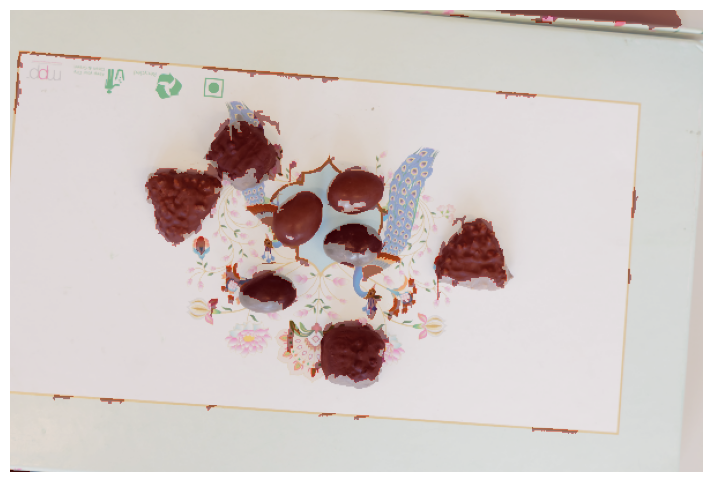

In [ ]:
plt.figure(figsize=(10,6))
plt.imshow(binned)
plt.imshow(binary, alpha=0.4, cmap='Reds')
plt.axis('off')
plt.show()

## Weaknesses of the segmentation pipeline
Here are the main weaknesses we observed with the current segmentation pipeline, and potential solution that we did not manage to explore. All ot these combined partially explain the disapointing results of the complete chocolate detection pipeline.

**Sensitivity to lighting:** \
As can be seen on the example above, the color of the chocolates is altered by the sideways lighting. This obviously changes how the pixels are spread in the color space. The impact of this effect is mostly limited to the value channel in HSV, but it remains a problem.

Super pixels that are exposed to direct light rarely belong to the same cluster as the rest of the chocolate. This applies particularily to smoother chocolates like _jelly milk_ and _passion au lait_ that reflect more light. We did not find a way to robustly overcome this issue, but is obviously has a significant impact shape dependent features such as compactness and fourier descriptors. 

**Unsupervised learning caveats:**\
One of the obvious issues of the pipeline is the fiability of the GMM clustering. The intra-class variance of the chocolate is quite big compared to the inter-class variance in color space, namely because the backgrounds include a large variety of colors. This results in far from ideal conditions for unsupervised ML techniques.

One solution could be to use alternative low level features, in addition to the color channels, such as local gradients and hessians to extract information about texture. There is however no guarantee these features wouldn't face the same problems as hsv channels. We did not find time to study a broader range of low level features and kept with hsv.

An alternative solution would be to manually annotate (some) chocolates in the training set to be able to use supervised ML methods, such as support vector machines. This is very likely to improve the quality of the segmentation, as it would enforce the learning a better encapsulation of the chocolate distribution in the feature space. This however still requires to select a set a low level features.

Another issue with our implementation is the choice of the number of components of the GMM. It is a know issue that the BIC metric tends to encourage a bigger number of components than necessary. Ideally, the BIC should display a clear elbow and start growing again but in our case quality of fit has more weight in the balance. An alternative to BIC that reduces over-fitting is likelyhood-based cross-validation, that relies on keeping a fraction of the data out of the fitting to evaluate the true generalization of the clustering. 


**Accuracy of the cluster selection:**\
Finally, even if the quality of the clustering is decent, the selection of the correct label is not guaranteed. We added the implementation of KL divergence and automatic label merging to reduce the classification errors. While these additions significantly reduced the amount of mistakes, it can still occur on some images.

When this happens, the output binary mask is usually completely useless for the rest of the pipeline and no chocolates are detected.




# Postprocessing of the Binary Masks

## Region Growing

A region growing algorithm was implemented to enhance the shape of the chocolates and get a better contours of the chocolates.

### Code necessary for the following explanation

The two cells below are the code explained above and are only here as they are necessary for the following explanations.

In [5]:
feat_ref = []
for name in config.names:
    ref = np.array(Image.open(config.reference_path+'/'+name+'.jpg'))
    annot = np.array(Image.open(config.annotated_path+'/'+name+'_annotated.jpg'), dtype=bool)

    binned = _utils.median_bin_rgb(ref, block_size=(10, 10))
    annot = block_reduce(annot, block_size=(10,10), func=np.median)

    binned_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
    binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)

    spx = slic(binned, n_segments=5000, compactness=.1, sigma=1, start_label=0)

    hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)
    h_ref = binned_hsv[annot>=1][:,0]/180
    s_ref = binned_hsv[annot>=1][:,1]/255
    v_ref = binned_hsv[annot>=1][:,2]/255

    hx_ref = np.cos(h_ref*2*np.pi)
    hy_ref = np.sin(h_ref*2*np.pi)
    
    feat_ref.append(np.array([hx_ref, hy_ref, s_ref, v_ref]).T)

feat_ref = np.vstack(feat_ref)
gmm_ref = GaussianMixture(n_components=1, covariance_type='full', reg_covar=1e-3)
gmm_ref.fit(feat_ref)

GaussianMixture(reg_covar=0.001)

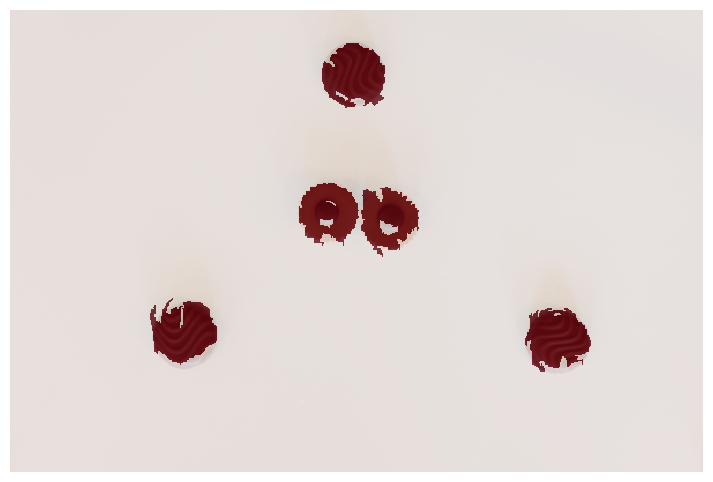

In [7]:
img = np.array(Image.open("../data/dataset_project_iapr2025/train/L1000792.JPG"))
binned = _utils.median_bin_rgb(img, block_size=(10, 10))

binned_hsv = _utils.rgb_to_hsv(binned)

spx = slic(binned, n_segments=10000, compactness=.05, sigma=0.1, start_label=0)

hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)

gmm = _utils.gmm_on_spx_fit(range(1,10), hsv_feat)
labels = _utils.gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

kl_divergences = np.full(np.max(labels)+1, np.inf)
for i in range(np.max(labels)+1):
    if len(binned_hsv[labels==i]) > 1000 and np.linalg.eigvals(gmm.covariances_[i]).max()<0.7:
        kl_divergences[i] = _utils.symmetric_kl(gmm.means_[i], gmm.covariances_[i], gmm_ref.means_[0], gmm_ref.covariances_[0])

best_label = np.argmin(kl_divergences)
merged = _utils.merge_labels(labels, best_label, 0.25)
binary = merged==best_label

plt.figure(figsize=(9,6))
plt.imshow(binned)
plt.imshow(binary, alpha=0.7, cmap='Reds', interpolation='none')
plt.axis('off')
plt.show()

### Functions

In [8]:
def mean_from_mask(img, mask):
    mean = np.mean(img[mask])
    return mean

def offset_range(img, mean, offset):
    img_range = ((img < mean + offset) & (img > mean - offset))
    return img_range

The functions `mean_from_mask` and `offset_range` are two simple functions used by the function `region_growing`:

- `mean_from_mask`: compute the mean value of a pixels of an image according to a mask.
- `offset_range`: compute a mask corresponding to a range of pixels value in an image.

In [11]:
def region_growing(rgb_img, hsv_img, mask):
    mask = skim.morphology.binary_closing(mask, skim.morphology.disk(5))
    mask = skim.morphology.remove_small_holes(mask, area_threshold=200)
    mask = skim.morphology.remove_small_objects(mask, min_size=50)
    mask = mask.astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    rg_mask = np.zeros_like(mask)
    rg_mask = rg_mask.astype(bool)

    for contour in contours:

        small_mask = np.zeros_like(mask)

        cv2.drawContours(small_mask, [contour], -1, 255, thickness=cv2.FILLED)

        small_mask = small_mask.astype(bool)

        mean_red = mean_from_mask(rgb_img[:,:,0], small_mask)
        mean_green = mean_from_mask(rgb_img[:,:,1], small_mask)
        mean_blue = mean_from_mask(rgb_img[:,:,2], small_mask)

        mean_hue = mean_from_mask(hsv_img[:,:,0], small_mask)
        mean_sat = mean_from_mask(hsv_img[:,:,1], small_mask)
        mean_val = mean_from_mask(hsv_img[:,:,2], small_mask)

        offset_hue = 80
        offset_sat = 60
        offset_val = 60

        offset_red = 45
        offset_green = 60
        offset_blue = 70
        
        labelled = (offset_range(hsv_img[:,:,0], mean_hue, offset_hue) & offset_range(hsv_img[:,:,1], mean_sat, offset_sat) & offset_range(hsv_img[:,:,2], mean_val, offset_val) &
                    offset_range(rgb_img[:,:,0], mean_red, offset_red) & offset_range(rgb_img[:,:,1], mean_green, offset_green) & offset_range(rgb_img[:,:,2], mean_blue, offset_blue))

        small_mask = skim.morphology.binary_erosion(small_mask, skim.morphology.disk(5))

        n_iterations = 10
        
        for i in range(n_iterations):         
            small_mask |= (skim.morphology.binary_dilation(small_mask, skim.morphology.disk(3)) & labelled)     

        rg_mask |= (small_mask == 1)

    rg_mask = skim.morphology.binary_closing(rg_mask, skim.morphology.disk(5))
    rg_mask = skim.morphology.remove_small_holes(rg_mask, area_threshold=1000)
    rg_mask = skim.morphology.remove_small_objects(rg_mask, min_size=50)
    return rg_mask

The function `region_growing` has three arguments, the image in RGB and in HSV and the mask computed before and it the region grown mask.

The differents steps performed in this function are:

1. Different skimage morphology functions are applied and the mask to remove small defects.
2. The contours are extracted from the mask. The region growing will be performed on one contour at a time.
3. For each contours:
    - A mask is created from the contour.
    - The mean value of the RBG and HSV channels are computed using the `mean_from_mask`function and the different acceptable offsets per channel are initialised.
    - The labelled variable is computed as the mask that is true for all the range computed according to the different channels and offsets using the function `offset_range`
    - The region growing is performed on 10 iterations. Before the region growing, an erosion is performed on the mask, it was observed that this erosion helped to get a more smooth final shape.
    - the region grown mask is added the new total mask.
4. Different skimage morphology functions are applied and the new mask to remove small defects.

This function performs a region growing algorithm per detected chocolate, the intent is to get a more finetuned region growing as the means are computed per detected region on not on the entire mask.



### Results

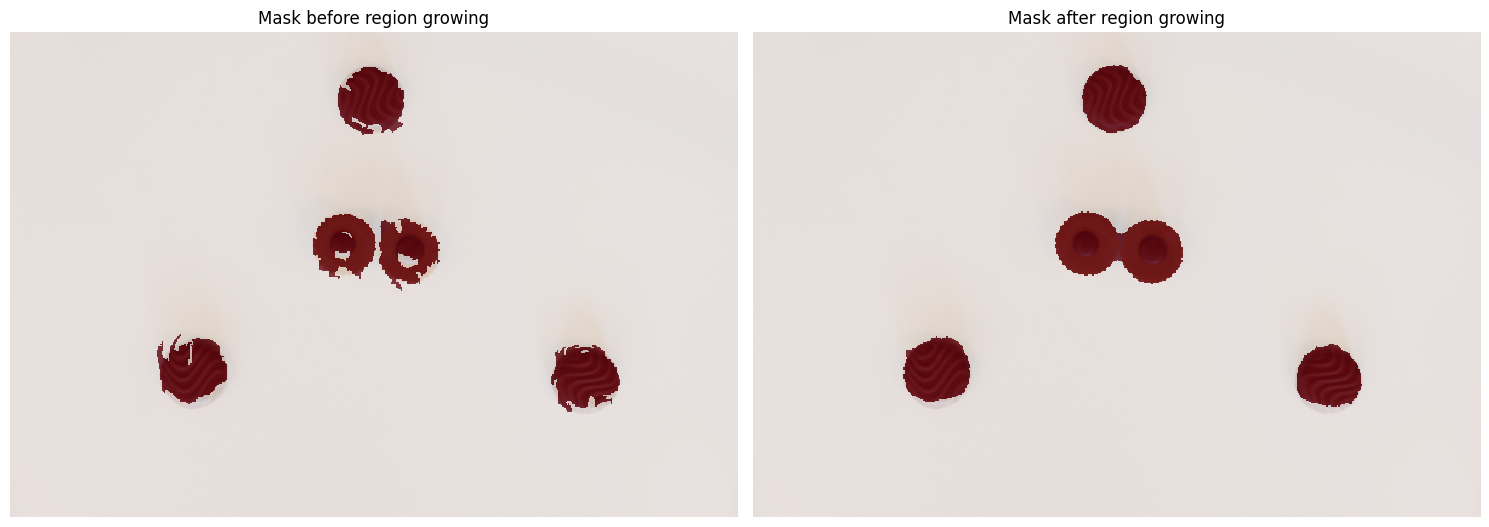

In [12]:
rg_mask = region_growing(binned, binned_hsv, binary)

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

ax[0].imshow(binned)
ax[0].imshow(binary, alpha=0.7, cmap='Reds', interpolation='none')
ax[0].set_title('Mask before region growing')
ax[0].axis('off')

ax[1].imshow(binned)
ax[1].imshow(rg_mask, alpha=0.7, cmap='Reds', interpolation='none')
ax[1].set_title('Mask after region growing')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Results from the region growing algorithm is shown above on an example, the mask is more refined and smooth after the region growing algorithm.

The region growing produce a unique final mask for all the chocolate, the separation of the different chocolates into different masks will be done in another function.

### Parameters finetuning

To get better offsets values for the RGB and HSV channels than what could be finetune by hand, the code below was run on the reference images, the goal was to see if the range of color that a chocolate use was roughly the same from one chocolate to another.

The standard deviation and the mean was calculated for all the chocolate and all the channels. The Gaussian distributions and the 2 standard deviation range values are plotted below.

##### Code used to get the different RGB and HSV channels of the reference chocolates.

In [15]:
list_channel = ['red', 'green', 'blue', 'hue', 'saturation', 'value']

std = np.zeros((len(list_channel), len(config.chocolates), 4))

for i in range(len(config.chocolates)):
    rgb_img = np.array(Image.open(config.reference_path+'/'+config.chocolates[i]+'.jpg'))
    hsv_img = _utils.rgb_to_hsv(rgb_img)

    mask = np.array(Image.open(config.annotated_path+'/'+config.chocolates[i]+'_annotated.jpg'))

    rgb_binned = _utils.median_bin_rgb(rgb_img, block_size=(10, 10))
    hsv_binned = _utils.median_bin_rgb(hsv_img, block_size=(10, 10))
    mask = skim.measure.block_reduce(mask, block_size=(10,10), func=np.median)
    mask = mask.astype(bool)

    rgb_pixels = rgb_binned[mask]
    hsv_pixels = hsv_binned[mask]

    for j in range(3):
        mu_rgb, std_rgb = scipy.stats.norm.fit(rgb_pixels[:,j])
        mu_hsv, std_hsv = scipy.stats.norm.fit(hsv_pixels[:,j])             
        std[j,i] = mu_rgb, std_rgb, min(rgb_pixels[:,j]), max(rgb_pixels[:,j])
        std[j+3,i] = mu_hsv, std_hsv, min(hsv_pixels[:,j]), max(hsv_pixels[:,j])       

##### Plots

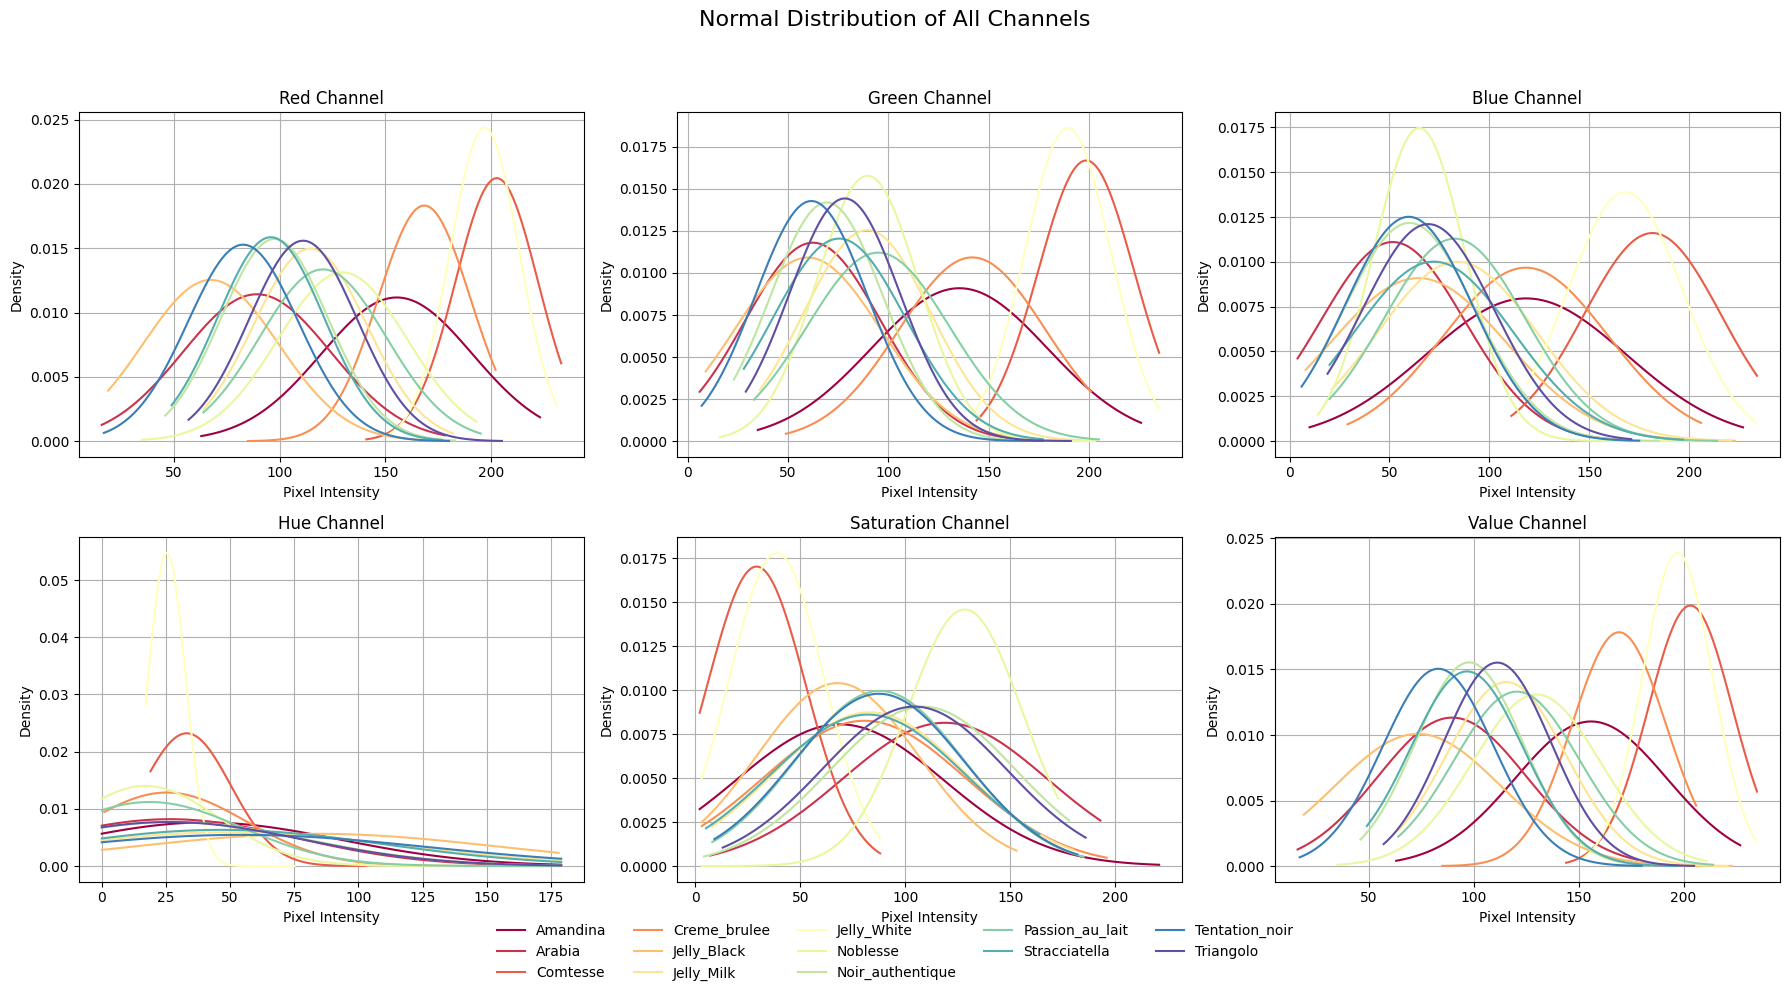

In [20]:
colors = cm.Spectral(np.linspace(0, 1, len(config.chocolates)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(len(list_channel)):
    ax = axes[i]
    for j in range(len(config.chocolates)):
        mu, std_dev, xmin, xmax = std[i][j]
        x = np.linspace(xmin, xmax, 100)
        pdf = scipy.stats.norm.pdf(x, mu, std_dev)
        ax.plot(x, pdf, color=colors[j], linewidth=1.5, label=config.chocolates[j])

    ax.set_title(f'{list_channel[i].capitalize()} Channel')
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Density')
    ax.grid(True)

fig.legend(config.chocolates.values(), loc='lower center', ncol=5, fontsize=10, frameon=False)
fig.suptitle('Normal Distribution of All Channels', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

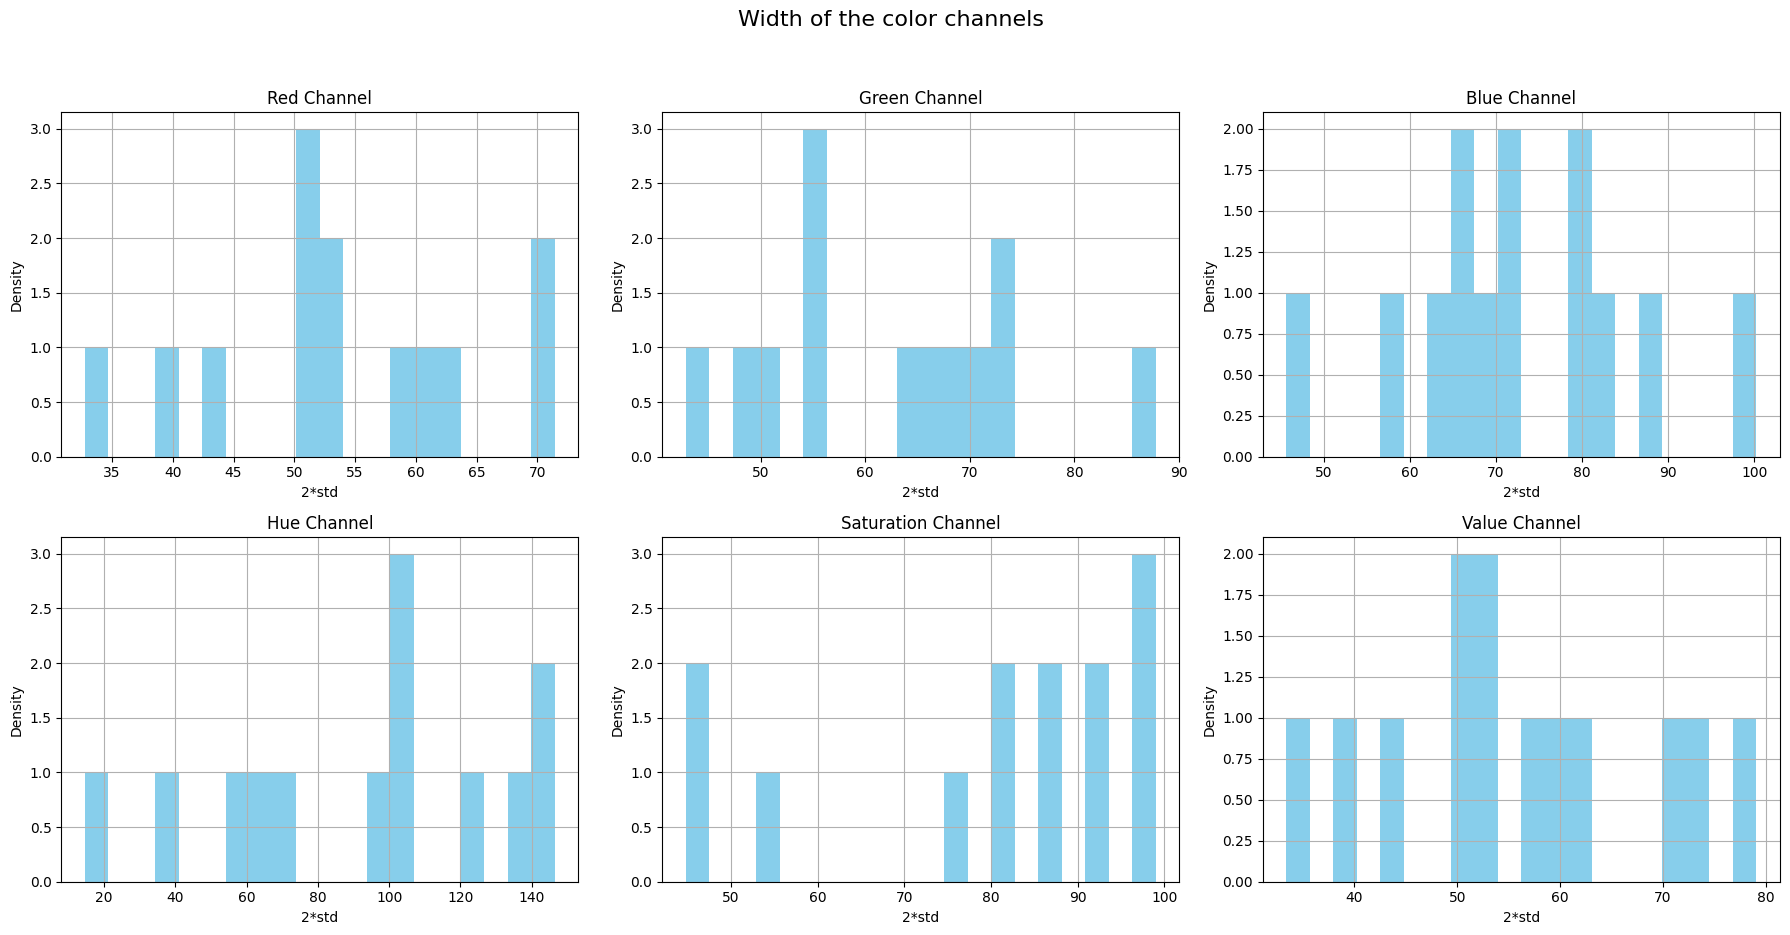

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(len(list_channel)):
    ax = axes[i]
    ranges = np.zeros((len(config.chocolates)))
    for j in range(len(config.chocolates)):
        ranges[j] = 2*std[i][j][1]
    
    ax.hist(ranges, bins=20, color='skyblue')
    ax.set_title(f'{list_channel[i].capitalize()} Channel')
    ax.set_xlabel('2*std')
    ax.set_ylabel('Density')
    ax.grid(True)

fig.suptitle('Width of the color channels ', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


From the graph above, a huge disparity in the range of colors that the chocolates occupy is observed.

This experiment did not provide satisfactory results to set better offset values in the `region_growing` function and the value used was thus chosen by hand while qualitatvely considering the graphs above.

## Watershed 

While a simple separation by contour is enough in some cases it does not work all the time because sometime chocolates are touching eachother.

To adresss this problem, a watershed algorithm was implemented.
Watershed is a segmentation technique base on simulating a water flood, the idea is to compute the distance of each pixel in the mask to its nearest edge. The computed distance can then be interpreted as height of some peaks, water can flood those created mountains and where water will meet the mask will be separated into two regions.





### Function

In [22]:
def watershed(mask):
        labels = skim.measure.label(mask)

        for i in range(labels.max()):
            area = (labels == i+1)
            if np.count_nonzero(area) > 2800:
                distance = scipy.ndimage.distance_transform_edt(area)
                coordinates = skim.feature.peak_local_max(distance, labels=area, footprint=skim.morphology.disk(10))

                local_maxi = np.zeros_like(distance, dtype=bool)
                local_maxi[tuple(coordinates.T)] = True

                markers = scipy.ndimage.label(local_maxi)[0]
                new_labels = skim.segmentation.watershed(-distance, markers, mask=area)
                new_labels[new_labels != 0] += labels.max()-i-1

                labels += new_labels

        for i in range(labels.max()):
            area = (labels == i+1)
            if np.count_nonzero(area) == 0:
                labels[labels > i] -= 1

        # Code to print the watershed results - not present in the _utils.py file
        plt.figure(figsize=(15, 7))
        
        plt.subplot(1, 3, 1)
        plt.imshow(binned, cmap='gray')
        plt.imshow(rg_mask, alpha=0.7, cmap='Reds', interpolation='none')
        plt.title("Mask before watershed")

        plt.subplot(1, 3, 2)
        plt.imshow(-distance, cmap='jet')
        plt.title("Inverted Distance Transform")

        plt.subplot(1, 3, 3)
        plt.imshow(skim.color.label2rgb(labels, image=binned, bg_label=0))
        plt.title("Mask after watershed")

        plt.tight_layout()
        plt.show()

        return labels


The function `watershed` has one argument, the mask computed before and it returns different labels, each label theoritcally corresponds to one chocolate.

The differents steps performed in this function are:

1. A skimage function is used to separate labels by contours.
2. If a label seems to big to contain only one chocolate, the watershed algorithm is applied:
    - The distance of each pixel to the closest edge is computed.
    - The coordinates of the local maxima are calculated and an stored in an image.
    - A label is given to every local maximum.
    - The watershed algorithm is applied using the skimage library.
3. Finally, some logics are applied to rearrange the labels in a better way.

 

### Results

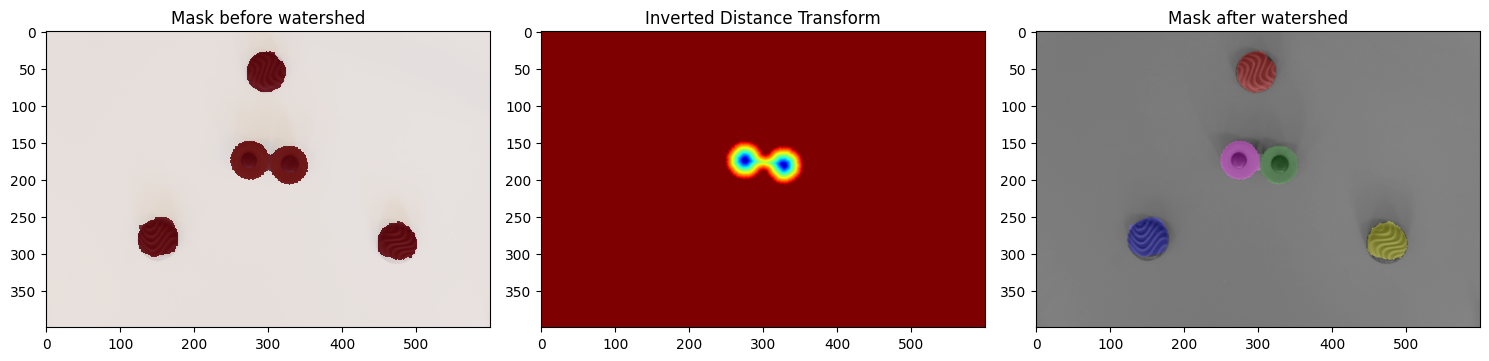

In [23]:
labels = watershed(rg_mask)

Results from the region watershed algorithm is shown above on an example:

- On the right, the two chocolates that touch eachother are separated into different labels.
- In the middle, the distance map is shown. The two local maxima are clearly visible.

The chocolates are seperated into distinct labels that can be classified to identified the chocolate present in the image. 

### Parameters finetuning

To quantify the threshold area above which the watershed algorithm will be applied, the code below was run on the reference images. The goal was to compute the area of each chocolate and decide what area could be considered as the threshold.

In [24]:
sizes_distribution = np.zeros((len(config.chocolates)))

for i in range(len(config.chocolates)):
    mask = np.array(Image.open(config.annotated_path+'/'+config.chocolates[i]+'_annotated.jpg'))

    mask = skim.measure.block_reduce(mask, block_size=(10,10), func=np.median)
    mask = mask.astype(bool)

    sizes_distribution[i] = np.count_nonzero(mask)    


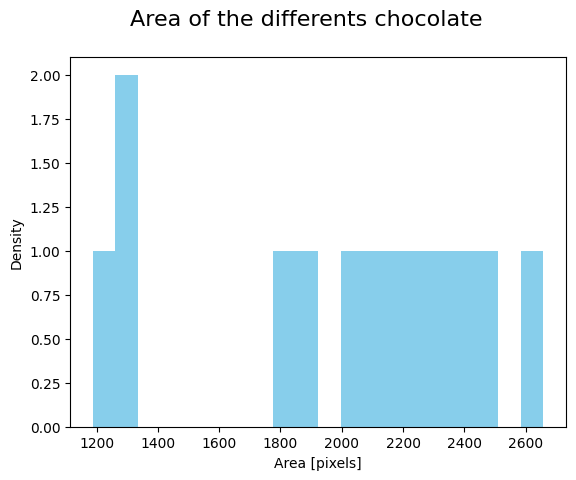

In [25]:
plt.hist(sizes_distribution, bins=20, color='skyblue')
plt.xlabel('Area [pixels]')
plt.ylabel('Density')
plt.suptitle('Area of the differents chocolate ', fontsize=16)
plt.show()

From the graph above, a huge disparity in the size of the chocolate is observed.

The threshold value chosen for the watershed algorithm is 2800px, it was chose above the maximum size of the chocolates with a margin of 200px.

### Conclusion

In this postprocessing part, two main algorithms were used, **region growing** and **watershed**. While the chosen example image gave ideal results, it was not the case for all the images in dataset. the chosen approach might have been too generalist.

To give better results, it would have been wiser to have a more per chocolate and background approach. While this approach might have better worked, we still find our approach interesting because it is a more general approach, if a new chocolate or background appear in the dataset, the region growing algorithm would still work and the watershed algorithm is only dependent of the chosen threshold size.

Our approach, gave us the chance to implement interesting concept seen in the course and more general function that are more interesting to study than manual thresholding on every chocolate and background.

# Classifier

### Open references and references annotated

Code below open both references and references annotated.

In [2]:
def compute_ref_choco():
    ref_choco = []
    for i in range(len(config.chocolates)):
        img = np.array(Image.open(config.reference_path+'/'+config.chocolates[i]+'.JPG'))
        binned_ref = _utils.median_bin_rgb(img, block_size=(10, 10))
        ref_choco.append(binned_ref)
    return ref_choco

def compute_ref_choco_annotated():
    ref_choco_annotated = []
    for i in range(len(config.chocolates)):
        img = np.array(Image.open(config.annotated_path+'/'+config.chocolates[i]+'_annotated.jpg'))
        binned_ref_annotated = skim.measure.block_reduce(img, block_size=(10, 10), func=np.median)
        N, M = binned_ref_annotated.shape
        for j in range(N):
            for k in range(M):
                if binned_ref_annotated[j][k] != 0:
                    binned_ref_annotated[j][k] = 1
                else:
                    binned_ref_annotated[j][k] = 0
        ref_choco_annotated.append(binned_ref_annotated)
    return ref_choco_annotated

In [ ]:
ref_choco = compute_ref_choco()

ref_choco_annotated = compute_ref_choco_annotated()

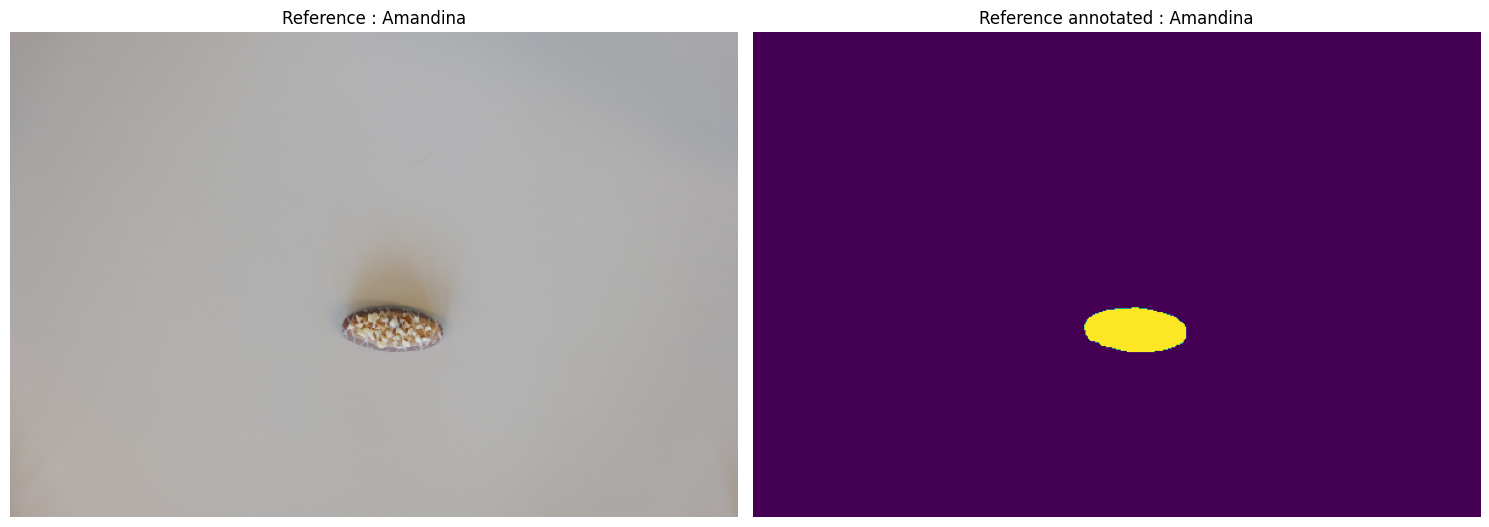

In [4]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.title('Reference : Amandina')
plt.imshow(ref_choco[0])
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Reference annotated : Amandina')
plt.imshow(ref_choco_annotated[0])
plt.axis('off')
plt.tight_layout()
plt.show()

An exemple of a reference and its binary image. We compute by hand the contour to have the most perfect form of all the chocolates. Thus, we have a good reference for each chocolate.

### Open an raw image to use as example

In [42]:
# Open raw image
example = np.array(Image.open('../final_group_08_ChocolateEaters8000/src/examples/L1000767.JPG'))
example = _utils.median_bin_rgb(example, block_size=(10, 10))

# Open image labeled after processing
example_labeled = np.array(Image.open('../final_group_08_ChocolateEaters8000/src/examples/L1000767_labels.png'))

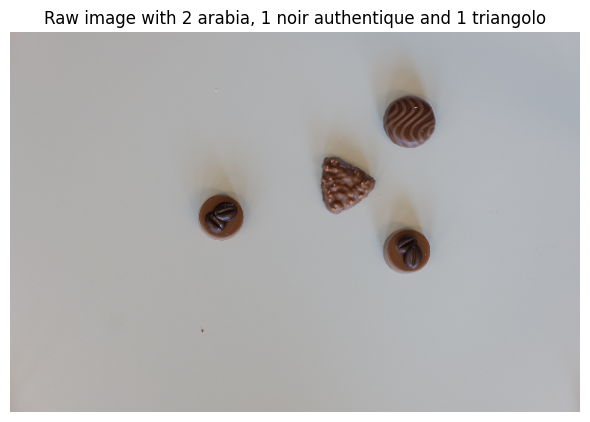

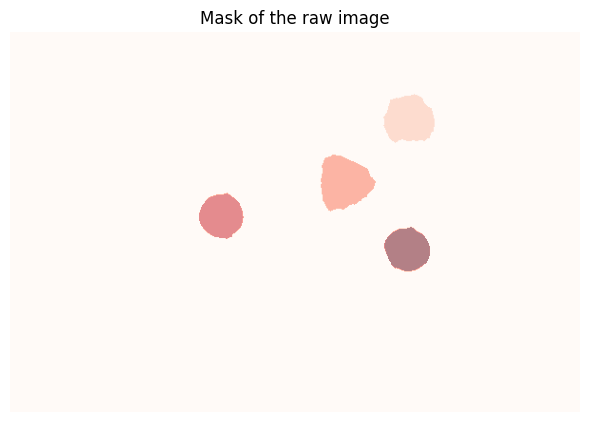

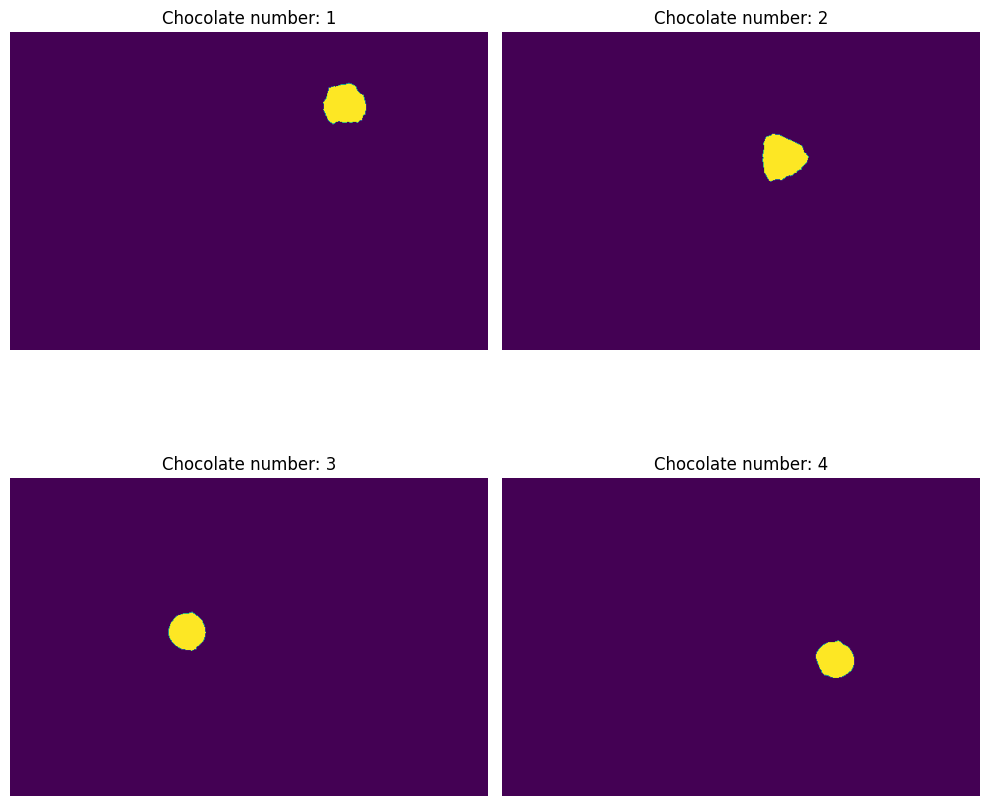

In [30]:
# plot the image, the mask and the mask after the watershed
plt.figure(figsize=(6, 6))
plt.title('Raw image with 2 arabia, 1 noir authentique and 1 triangolo')
plt.imshow(example)
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.title('Mask of the raw image')
plt.imshow(example_labeled, alpha=0.5, cmap='Reds')
plt.axis('off')
plt.tight_layout()
plt.show()

# plot each chocolate in order to assign a true label
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.title(f'Chocolate number: {i+1}')
    plt.imshow((example_labeled == i+1))
    plt.axis('off')

plt.tight_layout()

plt.show()

Here an example of one image with four chocolates on it. We can see the mask after the processing of the image to extract features. We will use this example to show how the classification works.

We also have the four chocolate masks in order and can now make a tabel with true label for each of them

In [31]:
# table with name of true chocolates in the image
true_chocolates = ['noir_authentique', 'triangolo', 'arabia', 'arabia']

### Classification

In this part, the goal is to detect all the chocolates in one image and to classify it with the gived references. To do this, we will use the mask create in the previous part to classify all the chocolate and extract features of the references and the objects to finally classify it.

### Extraction of features

First step is to extract both references and objects features. We extract the contours, the image with only the references/objects in RGB, the number of pixels not equal at zero in the image and the rectangularity. This is made for all the reference and for the image we analyse.

In [34]:
# Features references
contours_ref, choco, f_rect_ref, sum_choc_annotated = _utils.features_ref(len(ref_choco), ref_choco_annotated, ref_choco)

# Features objects
contours_object, diff_object, f_rect, array_sum = _utils.features_objects(np.max(example_labeled), example_labeled, example)

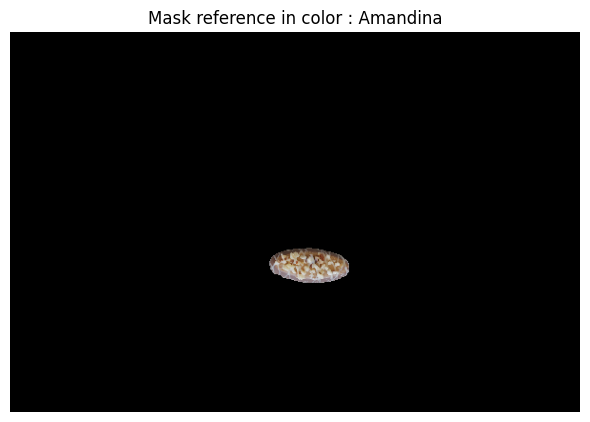

C:\Users\mikae\AppData\Local\Temp\ipykernel_24904\2665479403.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 17)


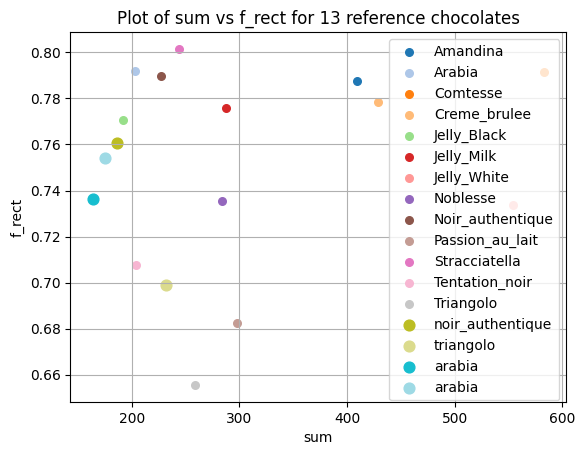

In [36]:
plt.figure(figsize=(6, 6))
plt.title('Mask reference in color : Amandina')
plt.imshow(choco[0])
plt.axis('off')
plt.tight_layout()
plt.show()

colors = plt.cm.get_cmap('tab20', 17)
for i in range(len(ref_choco_annotated)):
    plt.scatter(sum_choc_annotated[i], f_rect_ref[i], color=colors(i), label=config.chocolates[i], s=30)  # reference points, smaller
for i in range(len(diff_object)):
    plt.scatter(array_sum[i], f_rect[i], color=colors(i+13), label=true_chocolates[i], s=60)  # detected objects, bigger
plt.xlabel('sum')
plt.ylabel('f_rect')
plt.title('Plot of sum vs f_rect for 13 reference chocolates')
plt.legend()
plt.grid(True)
plt.show()

The graph above show a first look at how we proceed for the classification. We calcule the sum of all the pixels of the object and divide by the number of non-zero pixel to have a mean. We also calcul the rectangularity of the object. By comparing theses values with the references by making a treshold on the reference value, we can assign a chocolate type to the object. We can observe that due to the filter, the form of the detected chocolate are not perfect. Hence, the chocolates are close but not close enough to their reference to properly classify them. In this example, if we classify our chocolates with a threshold on both criterion, it will lead to false negatives. So We have to add one more criterion to better classify them and have less false positives or false negatives.

### Fourier descriptors

The third criterion we will add is the fourier descriptor. We will compare the reference with the object and choose the nearest reference as detected chocolate.

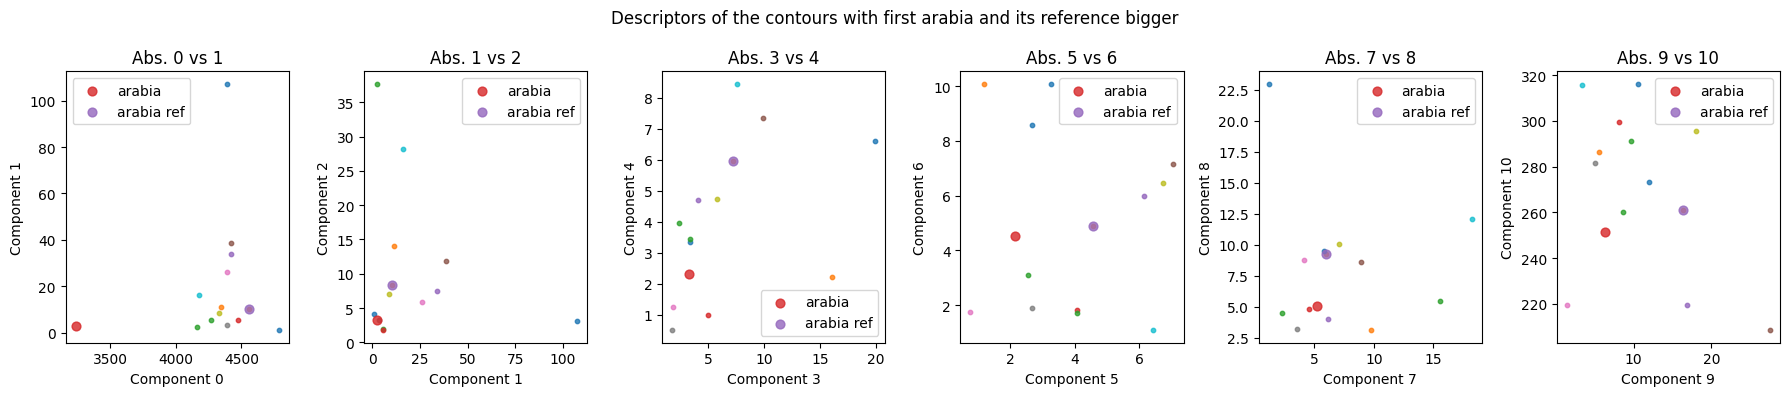

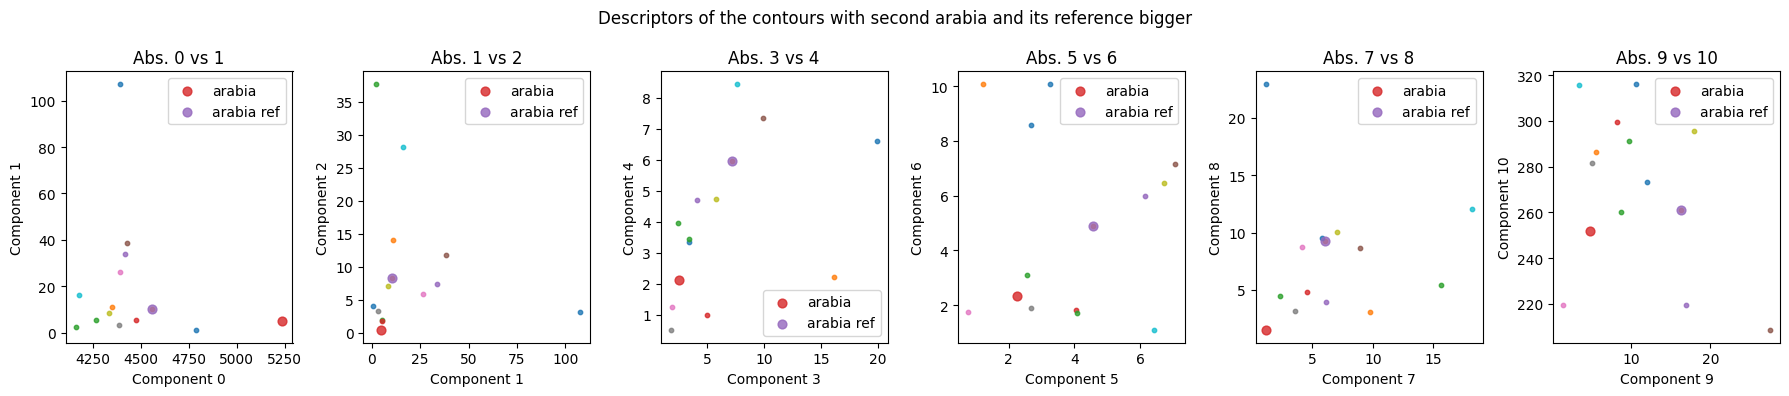

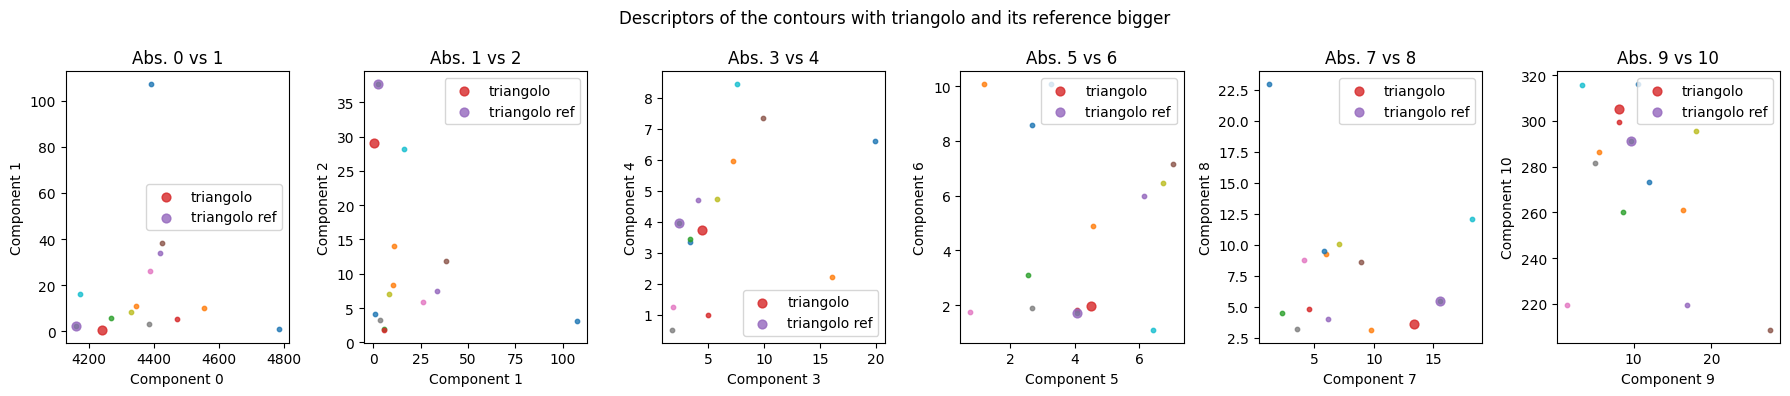

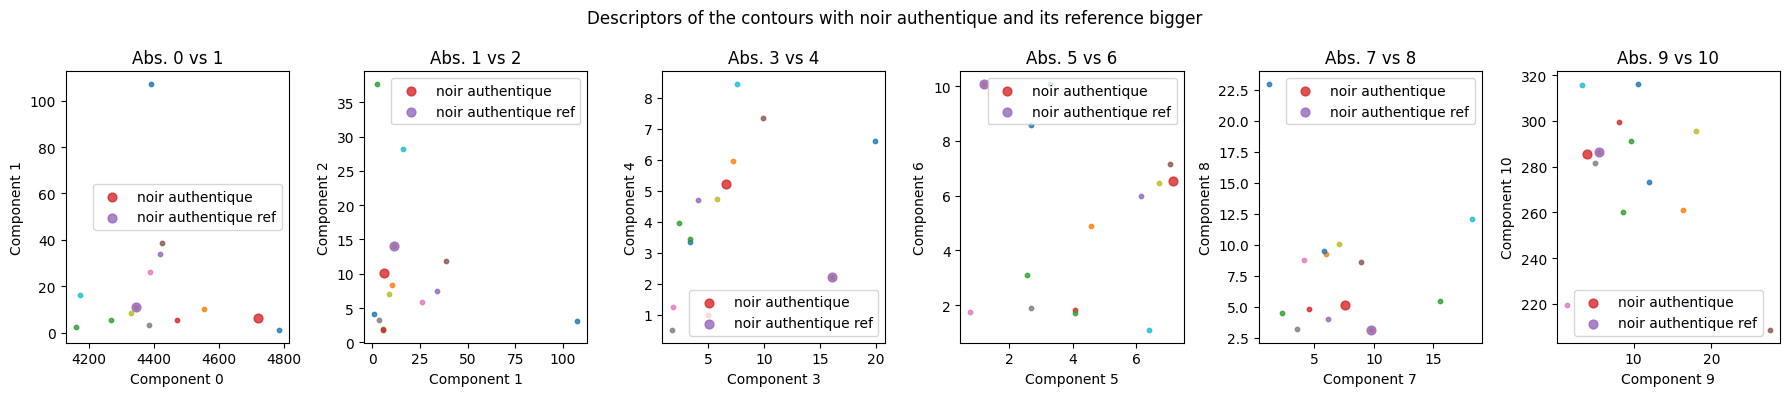

In [37]:
# Fourier descriptors
N = len(contours_ref)
n_samples = 11

contours_inter_ref = _utils.interpolation(contours_ref, n_samples)
descriptors_ref = _utils.compute_descriptor(contours_inter_ref, n_samples)

contours_inter_object = _utils.interpolation(contours_object, n_samples)
descriptors_object = _utils.compute_descriptor(contours_inter_object, n_samples)

# Plot features (plot 4 times to see each detected chocolate with its true reference)

# First plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[2, pa]), np.abs(descriptors_object[2, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with first arabia and its reference bigger")
plt.tight_layout()

# Second plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[3, pa]), np.abs(descriptors_object[3, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with second arabia and its reference bigger")
plt.tight_layout()


# Third plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[1, pa]), np.abs(descriptors_object[1, pb]), s=40, alpha=0.8, label='triangolo')
    axes[i].scatter(np.abs(descriptors_ref[12, pa]), np.abs(descriptors_ref[12, pb]), s=40, alpha=0.8, label='triangolo ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with triangolo and its reference bigger")
plt.tight_layout()

# Fourth plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[0, pa]), np.abs(descriptors_object[0, pb]), s=40, alpha=0.8, label='noir authentique')
    axes[i].scatter(np.abs(descriptors_ref[11, pa]), np.abs(descriptors_ref[11, pb]), s=40, alpha=0.8, label='noir authentique ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with noir authentique and its reference bigger")
plt.tight_layout()

In theses different graphs with different objects, we can observe two component more significant than others. Theses components are the 1, 2. We see on the graph that the object is near of the reference we want. But if we only take this two components, it will lead to too many false negatives. We need to made a mean with at least three pairs of components. By looking at theses graphs but also by testing on others images, the best pairs of components to take are pairs 1-2, 3-4 and 7-8. After making theses choices, we will proceed for each pair by calculate the euclidean distance between the object and all the reference, calculate a mean with the three pairs and choose the nearest reference as detected chocolate.

### Classifier

Finally, we build our classifier with the three criterion explained above. First, we detect which reference is the nearest of the object with the fourier descriptors. Second, we use the sum of the pixels and the rectangularity to be certain that the object is a chocolate and not a random object, this by analysing the mean color of the object and its form (sum of the pixels and rectangularity). We design a flexible threshold because a wrong turn countour of the chocolate at the processing stage can quickly alter the sum and rectangularity values. We can see that without the fourier descriptors, the flexibility of our threshold leads to many false negatives.

In [38]:
# Print the number of chocolates per image
nb_final_choc = np.zeros(len(ref_choco))
for n in range(len(array_sum)):
    dist_descriptor = []
    for i in range(len(ref_choco)):
        component_ref = np.concatenate([descriptors_ref[i][1:4], descriptors_ref[i][7:8]])
        component_object = np.concatenate([descriptors_object[n][1:4], descriptors_object[n][7:8]])
        vector = np.abs(np.abs(component_ref) - np.abs(component_object))
        dist_descriptor.append(np.linalg.norm(vector))
    closest_choco = np.argmin(dist_descriptor)
    print('closest chocolate:', config.chocolates[closest_choco])
    if ((sum_choc_annotated[closest_choco] - 100) < array_sum[n]) & (f_rect_ref[closest_choco] - 0.1 < f_rect[n]) & (f_rect_ref[closest_choco] + 0.1 > f_rect[n]):
        nb_final_choc[closest_choco] += 1

for i in range(len(ref_choco)):
    print(config.chocolates[i], ':', nb_final_choc[i], "chocolats dans l'image")

closest chocolate: Noir_authentique
closest chocolate: Triangolo
closest chocolate: Noblesse
closest chocolate: Comtesse
Amandina : 0.0 chocolats dans l'image
Arabia : 0.0 chocolats dans l'image
Comtesse : 0.0 chocolats dans l'image
Creme_brulee : 0.0 chocolats dans l'image
Jelly_Black : 0.0 chocolats dans l'image
Jelly_Milk : 0.0 chocolats dans l'image
Jelly_White : 0.0 chocolats dans l'image
Noblesse : 0.0 chocolats dans l'image
Noir_authentique : 1.0 chocolats dans l'image
Passion_au_lait : 0.0 chocolats dans l'image
Stracciatella : 0.0 chocolats dans l'image
Tentation_noir : 0.0 chocolats dans l'image
Triangolo : 1.0 chocolats dans l'image


In this example, only two chocolates are detected out of the four in the image. The cause was that one of the chocolates had a fourier descriptors closer to creme brulee than to arabia and the other closer to noblesse than arabia. We can see it in the plot with the fourier descriptors below

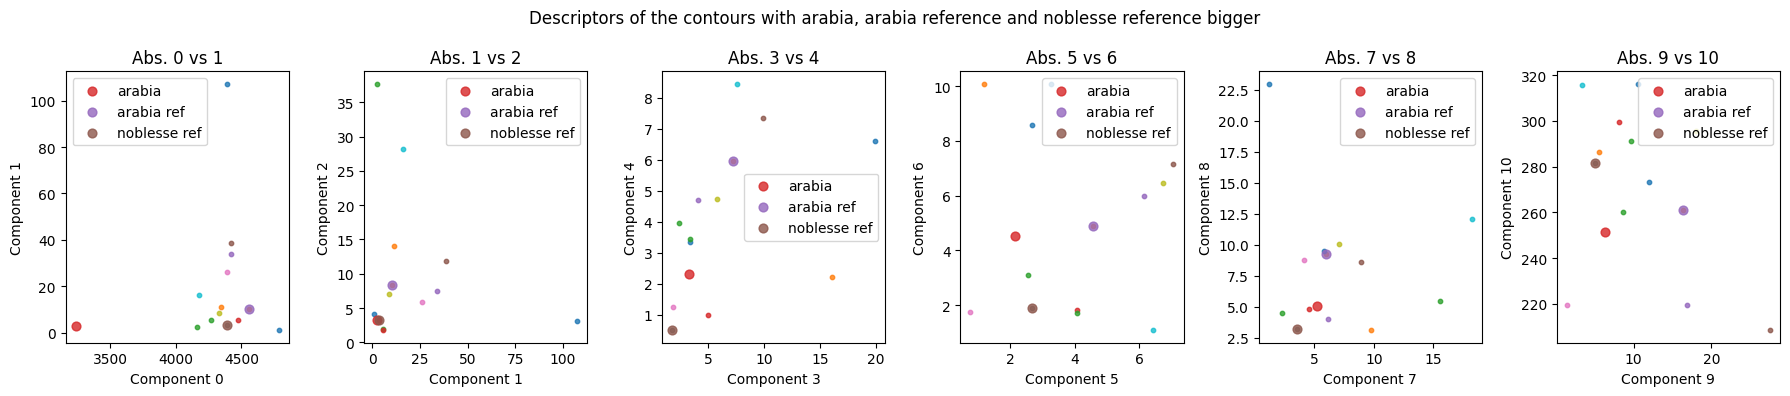

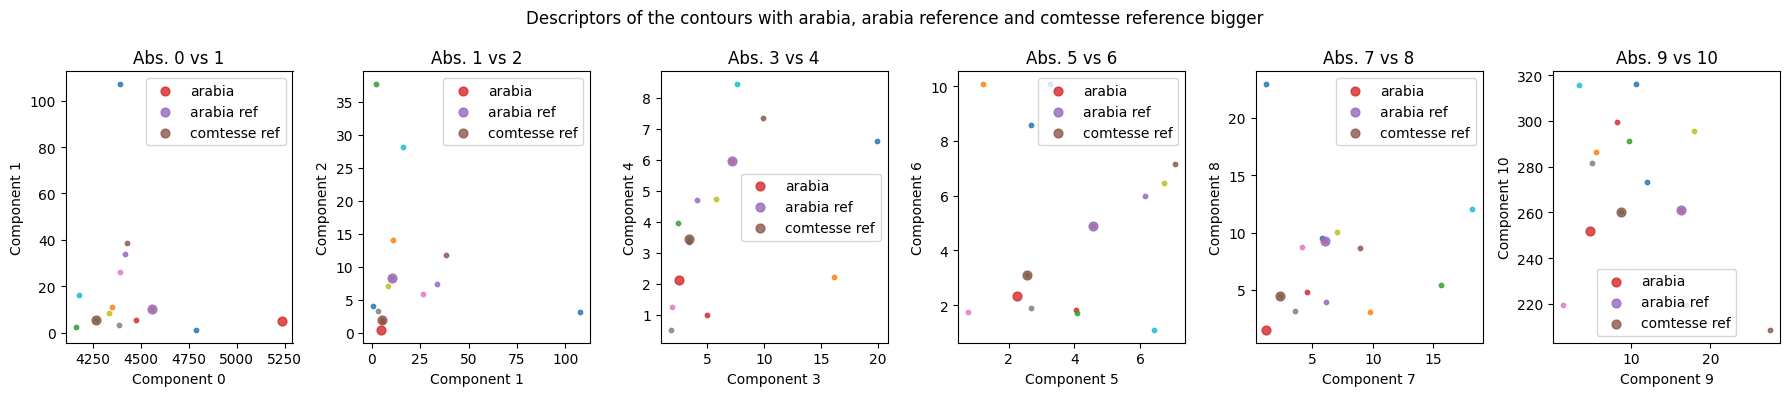

In [41]:
# Plot fourier descriptors with misinterpreted chocolate and arabia and creme brulee reference.
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[2, pa]), np.abs(descriptors_object[2, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].scatter(np.abs(descriptors_ref[7, pa]), np.abs(descriptors_ref[7, pb]), s=40, alpha=0.8, label='noblesse ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with arabia, arabia reference and noblesse reference bigger")
plt.tight_layout()

_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[3, pa]), np.abs(descriptors_object[3, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].scatter(np.abs(descriptors_ref[2, pa]), np.abs(descriptors_ref[2, pb]), s=40, alpha=0.8, label='comtesse ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with arabia, arabia reference and comtesse reference bigger")
plt.tight_layout()

Because of the mask, the two arabia chocolates are not well cropped. Hence, we easily see that for theses fourier descriptors, the reference of noblesse and comtesse are unfortunately closer from the object than arabia reference. This leads to two false negative in classification.

### Classification conclusion

**Weakness in the classification** \
In this classification, we try to use as many as possible features that we see in the course. By analysing many of them, we came up with an algorithm that use three very useful features.

**Fourier descriptors**: Transform the countours of the objects to use the fourier descriptors and choose the nearest reference to the object and assign this reference to the object.

**Sum of the color of the pixels**: Sum up all the pixels of the object and made a mean to approch the color of the references and not classify a random object with a different color than the references to a chocolate.

**Rectangularity**: use the function Regionprops() use in the lab 2 and extract the rectangularity of the object to not assign a random object with a good color but a different form than the references to a chocolate.

With theses three features together, we can provide a very good classification when considering perfect masks. The principal weakness of this classifier is that in the processing of the masks, these are not perfect and it leads to misinterpretation in the step with fourier descriptors that assign a wrong chocolate to the object and consequently to false negatives and positives, which reduces accuracy.